# Вопрос 12. Закон больших чисел. Центральная предельная теорема — численные примеры

Файл ведётся в формате jupytext (percent). Парный `.ipynb` получается
командой `make questions/12-lln-clt/examples.ipynb`; в git идёт **этот** файл,
ноутбук — производный артефакт.

**Сквозной пример один:** выборка независимых измерений одного датчика. Меняем
только закон шума и смотрим, что делает усреднение. Пять законов:

| Закон | Среднее | Дисперсия | Чего ждать |
|---|---|---|---|
| нормальный $\mathcal N(0,1)$ | 0 | 1 | эталон: ЗБЧ и ЦПТ работают |
| равномерный на $[-\sqrt3,\sqrt3]$ | 0 | 1 | лёгкие хвосты, ЦПТ быстрая |
| центрированный бернуллиевский, $p=0{,}05$ | 0 | 1 | редкие выбросы, сильная асимметрия |
| Парето, $\alpha=1{,}5$ | 3 | $\infty$ | ЗБЧ есть, ЦПТ нет |
| Коши | нет | нет | нет ничего |

В примере 3, где меряется скорость сходимости, к ним добавляются ещё два —
показательный (непрерывный, с известной асимметрией) и сумма двенадцати
равномерных: первый нужен как закон без решётки, второй разбирается как
генератор нормальных чисел.

Каждый пример отвечает на вопрос из `theory.md`; предсказание формулируется
**до** прогона и остаётся в тексте, даже если не сбылось.

In [1]:
from fractions import Fraction
from math import comb, factorial

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, integrate

SEED = 20260928

# One generator per example, all derived from a single seed. A shared stream
# would couple the examples: changing the ensemble size in example 1 shifts every
# sampled number downstream, and every golden pin with it.
rng_lln, rng_cauchy, rng_dice, rng_pareto = (
    np.random.default_rng([SEED, k]) for k in range(4)
)

FIGDIR = "figures"

# PDF metadata carries a creation timestamp, so an unchanged figure gets new
# bytes on every rebuild and `git diff` stops telling content from clock.
SAVE_KW = {"metadata": {"CreationDate": None}}

# Golden pins: seed AND expected output are frozen constants. Without the second
# half, "reproducibility" only checks a run against itself, which proves nothing.
# A mismatch aborts the notebook build, so the pin acts as a gate.
#
# Each tolerance is set per pin: a blanket 1e-3 would pass a value wrong in its
# fourth digit. Analytically determined quantities get 1e-12; Monte-Carlo ones
# get a tolerance that reflects the actual spread of the estimator.
GOLDEN = {
    # analytic or deterministic: tolerance at machine level
    "coin_N_cheb": (50000.0, 1e-12),
    "coin_N_clt": (9604.0, 1e-12),
    "ratio_cheb_clt": (5.206355432540114, 1e-12),
    "dice_halfwidth": (105.850153016853, 1e-12),
    "dice_len_ratio": (23.61829367976408, 1e-12),
    "D30_bern005": (0.21588062338436353, 1e-12),
    "sum12_sup": (0.002335925170854153, 1e-9),
    # sampled: tolerance reflects the spread of the estimator at this ensemble size
    "cauchy_iqr_N1000": (2.0, 0.05),
    "lln_slope_normal": (-0.5, 0.06),
    "pareto_iqr_alpha_last": (3.77285951027, 0.03),
    "pareto_local_slope": (0.191586032695, 0.06),
}


def check_golden(name, value):
    want, tol = GOLDEN[name]
    rel = abs(value - want) / max(abs(want), 1e-300)
    print(f"  пин {name}: получено {value:.12g}, ожидалось {want:.12g} (допуск {tol:g})")
    assert rel <= tol, f"golden-пин {name} не сошёлся: {value} vs {want}"

## Законы шума

Первые три нормированы к нулевому среднему и единичной дисперсии, чтобы
сравнение шло при прочих равных. Парето и Коши нормировать нечем: у первого
дисперсии нет, у второго нет и среднего.

In [2]:
ALPHA_PARETO = 1.5          # Pareto tail index: 1 < a < 2 -> mean exists, variance does not
P_RARE = 0.05               # rare event: a strongly skewed indicator


def draw_normal(size):
    return rng_lln.standard_normal(size)


def draw_uniform(size):
    return rng_lln.uniform(-np.sqrt(3), np.sqrt(3), size)


def draw_bernoulli(size):
    q = 1.0 - P_RARE
    return (rng_lln.random(size) < P_RARE) / np.sqrt(P_RARE * q) - P_RARE / np.sqrt(P_RARE * q)


def draw_pareto(size):
    # numpy's pareto(a) returns X with P(X > x) = (1+x)^{-a}; shift to the classical form
    return rng_lln.pareto(ALPHA_PARETO, size) + 1.0


def draw_cauchy(size):
    return rng_lln.standard_cauchy(size)


LAWS = {
    "нормальный": (draw_normal, 0.0),
    "равномерный": (draw_uniform, 0.0),
    f"бернуллиевский, p={P_RARE}": (draw_bernoulli, 0.0),
    f"Парето, a={ALPHA_PARETO}": (draw_pareto, ALPHA_PARETO / (ALPHA_PARETO - 1.0)),
    "Коши": (draw_cauchy, np.nan),
}

print("средние законов (nan = не существует):")
for name, (_, a) in LAWS.items():
    print(f"  {name:28s} a = {a}")

средние законов (nan = не существует):
  нормальный                   a = 0.0
  равномерный                  a = 0.0
  бернуллиевский, p=0.05       a = 0.0
  Парето, a=1.5                a = 3.0
  Коши                         a = nan


## Пример 1. Закон больших чисел в действии и его отсутствие

**Вопрос.** Что делает выборочное среднее $\overline X_N$ при росте $N$ для
каждого из пяти законов?

**Предсказание (до прогона).** Для первых трёх законов работает следствие
из слабого закона больших чисел: $|\overline X_N - a|$ убывает как
$N^{-1/2}$, то есть наклон в логарифмических осях равен $-0{,}5$. Для Парето с
$\alpha=1{,}5$ среднее конечно, и по теореме Хинчина сходимость есть, но
дисперсии нет — наклон должен быть положе, около $1/\alpha-1=-1/3$. Для Коши
сходимости нет вовсе: $\overline X_N$ распределено при каждом $N$ так же, как
одно наблюдение, поэтому разброс траекторий по ансамблю прогонов
**не сужается**, а наклон будет около нуля.

Медиана считается по $200$ прогонам, а не по восьми: медиана восьми значений
сама имеет разброс в три раза, то есть порядка измеряемого эффекта.

In [3]:
N_MAX = 100_000
N_RUNS_MED = 200            # ensemble for the median curves
N_RUNS_TRAJ = 8             # individual trajectories shown on the right panel
CHUNK = 25                  # runs per block: keeps the cumsum buffer under ~20 MB
grid = np.unique(np.logspace(0, np.log10(N_MAX), 220).astype(int))


def median_deviation(draw, a, n_runs=N_RUNS_MED):
    """Median |mean_N - a| over an ensemble, evaluated on `grid`.

    Eight runs were not enough: the median of eight draws carries a factor-three
    spread, which is the size of the effect being measured.
    """
    acc = []
    for _ in range(n_runs // CHUNK):
        x = draw((CHUNK, N_MAX))
        means = np.cumsum(x, axis=1) / np.arange(1, N_MAX + 1)
        acc.append(np.abs(means[:, grid - 1] - a))
    return np.median(np.concatenate(acc, axis=0), axis=0)


dev = {}
tail = grid >= 1000         # fit the slope over the last two decades only
print(f"{'закон':>28} {'|X̄_N - a| при N=10^5':>22} {'наклон на [10^3; 10^5]':>24}")
for name, (draw, a) in LAWS.items():
    ref = 0.0 if np.isnan(a) else a
    dev[name] = median_deviation(draw, ref)
    slope = np.polyfit(np.log(grid[tail]), np.log(dev[name][tail]), 1)[0]
    print(f"{name:>28} {dev[name][-1]:22.5f} {slope:+24.4f}")
    if name == "нормальный":
        slope_normal = slope
check_golden("lln_slope_normal", slope_normal)

traj_cauchy = np.cumsum(rng_lln.standard_cauchy((N_RUNS_TRAJ, N_MAX)), axis=1)
traj_cauchy = traj_cauchy / np.arange(1, N_MAX + 1)
traj_cauchy = traj_cauchy[:, grid - 1]

                       закон  |X̄_N - a| при N=10^5   наклон на [10^3; 10^5]


                  нормальный                0.00195                  -0.5148


                 равномерный                0.00208                  -0.5104


      бернуллиевский, p=0.05                0.00193                  -0.5472


               Парето, a=1.5                0.04661                  -0.3028


                        Коши                1.07632                  +0.0153
  пин lln_slope_normal: получено -0.514753823798, ожидалось -0.5 (допуск 0.06)


Разброс траекторий Коши по ансамблю прогонов меряется межквартильным
размахом. Теория даёт точное значение: $\overline X_N$ имеет стандартное
распределение Коши при любом $N$, его квартили равны $\pm1$, значит
межквартильный размах равен $2$ при всех $N$.

In [4]:
M_RUNS = 20_000
for N in (1, 10, 100, 1000):
    sample = rng_cauchy.standard_cauchy((M_RUNS, N)).mean(axis=1)
    iqr = np.subtract(*np.percentile(sample, [75, 25]))
    print(f"  Коши, N = {N:5d}: межквартильный размах X̄_N = {iqr:.4f}")
    if N == 1000:
        cauchy_iqr = iqr
check_golden("cauchy_iqr_N1000", cauchy_iqr)

  Коши, N =     1: межквартильный размах X̄_N = 1.9816
  Коши, N =    10: межквартильный размах X̄_N = 1.9980
  Коши, N =   100: межквартильный размах X̄_N = 2.0119


  Коши, N =  1000: межквартильный размах X̄_N = 1.9871
  пин cauchy_iqr_N1000: получено 1.9870832912, ожидалось 2 (допуск 0.05)


**Вывод.** Предсказание сбылось, и теперь это утверждение о числах, а не о
виде кривой: измеренные наклоны на двух последних декадах равны $-0{,}515$
(нормальный), $-0{,}510$ (равномерный), $-0{,}547$ (бернуллиевский),
$-0{,}303$ (Парето, предсказано $-1/3$) и $+0{,}015$ (Коши, предсказано $0$).
Отклонения от предсказанных значений — разброс оценки: медиана по $200$
прогонам сама имеет относительную погрешность около $8\,\%$, и наклон,
подогнанный по двум декадам, определён примерно до $\pm0{,}03$; сильнее всех
гуляет бернуллиевский закон, у которого уклонение задаётся редкими выбросами.
Существенно другое: три закона с конечной дисперсией дают наклон около
$-1/2$, Парето — заметно положе, а Коши — ноль. Парето сходится
ступенями — каждая ступень есть одно большое наблюдение, поглощаемое затем
ростом $N$. У Коши межквартильный размах выборочного среднего равен $2$ при
$N=1$ и при $N=1000$ одинаково, то есть тысяча измерений не лучше одного. Это
и есть отказ теоремы Хинчина при $\E|\xi| = \infty$.

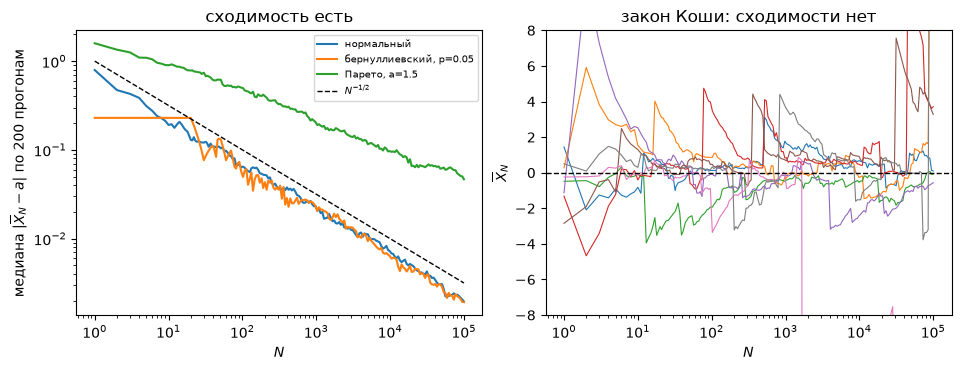

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6), layout="constrained")
for name in ("нормальный", f"бернуллиевский, p={P_RARE}", f"Парето, a={ALPHA_PARETO}"):
    axes[0].loglog(grid, dev[name], label=name)
axes[0].loglog(grid, 1.0 / np.sqrt(grid), "k--", lw=1, label=r"$N^{-1/2}$")
axes[0].set_xlabel("$N$")
axes[0].set_ylabel(r"медиана $|\overline{X}_N - a|$ по 200 прогонам")
axes[0].set_title("сходимость есть")
axes[0].legend(fontsize=7)

for r in range(N_RUNS_TRAJ):
    axes[1].semilogx(grid, traj_cauchy[r], lw=0.8)
axes[1].axhline(0.0, color="k", lw=1, ls="--")
axes[1].set_ylim(-8, 8)
axes[1].set_xlabel("$N$")
axes[1].set_ylabel(r"$\overline{X}_N$")
axes[1].set_title("закон Коши: сходимости нет")
fig.savefig(f"{FIGDIR}/fig-01.pdf", **SAVE_KW)

## Пример 2. Сколько нужно измерений: Чебышёв против ЦПТ

**Вопрос.** Первая разобранная задача конспекта: сколько бросков монеты нужно,
чтобы частота герба отличалась от $1/2$ не более чем на $\varepsilon=0{,}01$
с вероятностью $0{,}95$? Два ответа — по неравенству Чебышёва и по теореме
Муавра — Лапласа. Каков каждый и каково фактическое покрытие при каждом?

**Предсказание (до прогона).** Отношение объёмов равно
$1/(\alpha z^2_{1-\alpha/2}) \approx 5{,}2$ и не зависит ни от $\sigma$, ни
от $\varepsilon$. Фактическое покрытие при $N_{\text{ЦПТ}}$ будет близко к
$0{,}95$ (слагаемые симметричны, $N$ велико), при $N_{\text{Ч}}$ — почти
единица: оценка Чебышёва израсходована не полностью. Для асимметричного
случая $p=0{,}05$ покрытие по ЦПТ будет заметно хуже заявленного.

In [6]:
eps, alpha = 0.01, 0.05
z = stats.norm.ppf(1 - alpha / 2)
print(f"z_(1-alpha/2) = {z:.6f}")


def sample_sizes(sigma2, eps, alpha, z):
    return sigma2 / (alpha * eps**2), (z * np.sqrt(sigma2) / eps) ** 2


for p in (0.5, P_RARE):
    s2 = p * (1 - p)
    n_cheb, n_clt = sample_sizes(s2, eps, alpha, z)
    print(f"p = {p}: sigma^2 = {s2:.4f}, N_Ч = {np.ceil(n_cheb):.0f}, "
          f"N_ЦПТ = {np.ceil(n_clt):.0f}, отношение = {n_cheb / n_clt:.4f}")
    if p == 0.5:
        coin_cheb, coin_clt = n_cheb, n_clt

check_golden("coin_N_cheb", coin_cheb)
check_golden("coin_N_clt", np.ceil(coin_clt))
check_golden("ratio_cheb_clt", coin_cheb / coin_clt)

z_(1-alpha/2) = 1.959964
p = 0.5: sigma^2 = 0.2500, N_Ч = 50000, N_ЦПТ = 9604, отношение = 5.2064
p = 0.05: sigma^2 = 0.0475, N_Ч = 9500, N_ЦПТ = 1825, отношение = 5.2064
  пин coin_N_cheb: получено 50000, ожидалось 50000 (допуск 1e-12)
  пин coin_N_clt: получено 9604, ожидалось 9604 (допуск 1e-12)
  пин ratio_cheb_clt: получено 5.20635543254, ожидалось 5.20635543254 (допуск 1e-12)


Фактическое покрытие считается точно: число успехов имеет биномиальное
распределение, и вероятность попадания частоты в интервал выписывается через
его функцию распределения — моделировать не нужно.

In [7]:
def exact_coverage(N, p, eps):
    """Exact P{|mu/N - p| <= eps} for mu ~ Bin(N, p); no simulation needed."""
    N = int(np.ceil(N))
    lo = np.ceil(N * (p - eps) - 1e-12)
    hi = np.floor(N * (p + eps) + 1e-12)
    return stats.binom.cdf(hi, N, p) - stats.binom.cdf(lo - 1, N, p)


print("фактическое покрытие интервала |частота - p| <= eps:")
for p in (0.5, P_RARE):
    s2 = p * (1 - p)
    n_cheb, n_clt = sample_sizes(s2, eps, alpha, z)
    print(f"  p = {p:4}:  при N_ЦПТ = {np.ceil(n_clt):6.0f} -> {exact_coverage(n_clt, p, eps):.4f}"
          f"   при N_Ч = {np.ceil(n_cheb):6.0f} -> {exact_coverage(n_cheb, p, eps):.4f}")

фактическое покрытие интервала |частота - p| <= eps:
  p =  0.5:  при N_ЦПТ =   9604 -> 0.9511   при N_Ч =  50000 -> 1.0000
  p = 0.05:  при N_ЦПТ =   1825 -> 0.9532   при N_Ч =   9500 -> 1.0000


Вторая половина примера — вторая разобранная задача конспекта: сумма очков при
$1000$ бросках кости.

In [8]:
faces = np.arange(1, 7)
m1 = faces.mean()
d1 = (faces**2).mean() - m1**2
N_DICE = 1000
mu_dice, sd_dice = N_DICE * m1, np.sqrt(N_DICE * d1)
half = z * sd_dice
print(f"один бросок: E = {m1}, D = {d1:.6f} (= 35/12 = {35/12:.6f})")
print(f"сумма 1000 бросков: E = {mu_dice:.1f}, sigma = {sd_dice:.4f}")
print(f"полуширина 95%-интервала = {half:.4f}, интервал [{mu_dice-half:.1f}; {mu_dice+half:.1f}]")
print(f"длина = {2*half:.4f}, тривиальный интервал [1000; 6000] длиной 5000, "
      f"отношение = {5000/(2*half):.4f}")
check_golden("dice_halfwidth", half)
check_golden("dice_len_ratio", 5000 / (2 * half))

dice = rng_dice.integers(1, 7, size=(20_000, N_DICE), dtype=np.int8).sum(axis=1, dtype=np.int32)
cover = np.mean(np.abs(dice - mu_dice) <= half)
print(f"фактическое покрытие по 20000 прогонам: {cover:.4f}")

один бросок: E = 3.5, D = 2.916667 (= 35/12 = 2.916667)
сумма 1000 бросков: E = 3500.0, sigma = 54.0062
полуширина 95%-интервала = 105.8502, интервал [3394.1; 3605.9]
длина = 211.7003, тривиальный интервал [1000; 6000] длиной 5000, отношение = 23.6183
  пин dice_halfwidth: получено 105.850153017, ожидалось 105.850153017 (допуск 1e-12)
  пин dice_len_ratio: получено 23.6182936798, ожидалось 23.6182936798 (допуск 1e-12)
фактическое покрытие по 20000 прогонам: 0.9468


Предсказание про асимметрию не сбылось, и прежде чем объяснять, проверим, при
каких $N$ оно вообще должно было бы сбыться: посчитаем точное покрытие
симметричного интервала $|\mu_N-Np|\le z\sqrt{Npq}$ при $p=0{,}05$ для малых
$N$ тоже.

In [9]:
def coverage_sym(N, p):
    """Exact P{|mu - Np| <= z*sqrt(Npq)} — the two-sided CLT interval."""
    N = int(N)
    sd = np.sqrt(N * p * (1 - p))
    lo = np.ceil(N * p - z * sd - 1e-12)
    hi = np.floor(N * p + z * sd + 1e-12)
    return stats.binom.cdf(hi, N, p) - stats.binom.cdf(lo - 1, N, p)


print("покрытие симметричного интервала по ЦПТ при p = 0.05 и малых N:")
for n in (10, 30, 50, 100, 300, 1000, 1825):
    print(f"  N = {n:5d}  Np = {n*P_RARE:6.2f}  покрытие = {coverage_sym(n, P_RARE):.4f}")

покрытие симметричного интервала по ЦПТ при p = 0.05 и малых N:
  N =    10  Np =   0.50  покрытие = 0.9139
  N =    30  Np =   1.50  покрытие = 0.9392
  N =    50  Np =   2.50  покрытие = 0.9622
  N =   100  Np =   5.00  покрытие = 0.9659
  N =   300  Np =  15.00  покрытие = 0.9548
  N =  1000  Np =  50.00  покрытие = 0.9504
  N =  1825  Np =  91.25  покрытие = 0.9471


**Вывод.** Предсказание сбылось во всём, кроме одного места, и это место
содержательно. Отношение объёмов равно $5{,}21$ для обоих значений $p$, то
есть действительно не зависит от закона. Покрытие по Чебышёву при $p=0{,}5$
практически единично — вся разница в объёме уходит в неиспользованный запас
надёжности.

А вот покрытие по ЦПТ при $p=0{,}05$ оказалось **не хуже**, чем при
$p=0{,}5$, и таблица выше показывает, что дело не в величине $N$: уже при
$N=30$, когда $Np=1{,}5$, покрытие равно $0{,}9392$, а при $N=50$ — $0{,}9622$.
То есть симметричный двусторонний интервал устойчив к асимметрии с самого
начала.

Причина в том, какой именно функционал меряется. Ведущая поправка к
нормальному приближению нечувствительна к знаку аргумента — она чётна по $x$,
— и потому в симметричной разности $F(c)-F(-c)$ сокращается. В одностороннем
уклонении $\sup_x|F-\Phi|$ сокращаться нечему, и там асимметрия видна в полную
силу: при $N=30$ и $p=0{,}05$ одностороннее уклонение равно $0{,}216$
(пример 3), а ошибка двустороннего покрытия при том же $N$ — $0{,}011$, в
двадцать раз меньше. Практический вывод: асимметрия слагаемого бьёт по
односторонним оценкам и по квантилям хвостов, а не по объёму выборки,
рассчитанному на симметричный интервал.

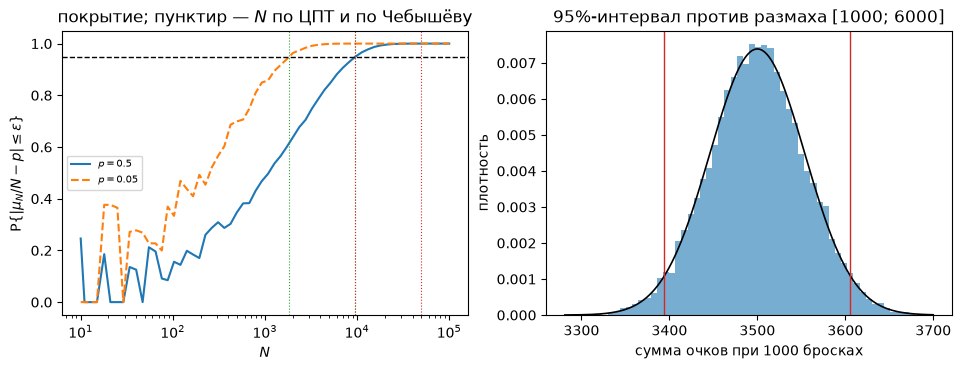

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6), layout="constrained")
Ns = np.unique(np.logspace(1, 5, 60).astype(int))
for p, style in ((0.5, "-"), (P_RARE, "--")):
    cov = [exact_coverage(n, p, eps) for n in Ns]
    axes[0].semilogx(Ns, cov, style, label=f"$p={p}$")
    n_cheb, n_clt = sample_sizes(p * (1 - p), eps, alpha, z)
    axes[0].axvline(n_clt, color="C2", lw=0.8, ls=":")
    axes[0].axvline(n_cheb, color="C3", lw=0.8, ls=":")
axes[0].axhline(1 - alpha, color="k", lw=1, ls="--")
axes[0].set_xlabel("$N$")
axes[0].set_ylabel(r"$\mathsf{P}\{|\mu_N/N - p| \leq \varepsilon\}$")
axes[0].set_title("покрытие; пунктир — $N$ по ЦПТ и по Чебышёву")
axes[0].legend(fontsize=7)

axes[1].hist(dice, bins=60, density=True, color="C0", alpha=0.6)
xx = np.linspace(dice.min(), dice.max(), 400)
axes[1].plot(xx, stats.norm.pdf(xx, mu_dice, sd_dice), "k-", lw=1.2)
for s in (-1, 1):
    axes[1].axvline(mu_dice + s * half, color="C3", lw=1)
axes[1].set_xlabel("сумма очков при 1000 бросках")
axes[1].set_ylabel("плотность")
axes[1].set_title("95%-интервал против размаха [1000; 6000]")
fig.savefig(f"{FIGDIR}/fig-02.pdf", **SAVE_KW)

## Пример 3. Скорость сходимости в ЦПТ и цена асимметрии

**Вопрос.** Как быстро $F_{\zeta_N}$ приближается к $\Phi$ и от чего зависит
множитель? Верно ли ходовое правило «$N \geq 30$ достаточно»?

**Предсказание (до прогона).** По структуре оценки Берри — Эссеена
$\sup_x|F_{\zeta_N}(x) - \Phi(x)| \leq C\rho_3/(\sigma^3\sqrt N)$ ожидаем:
величина $D_N\sqrt N$ выходит на постоянную, и эта постоянная
**пропорциональна** $\rho_3/\sigma^3$. Для бернуллиевского закона
$\rho_3/\sigma^3 = (p^2+q^2)/\sqrt{pq}$: при $p=0{,}5$ это $1$, при
$p=0{,}05$ — около $4{,}2$. Значит при $p=0{,}05$ для той же точности нужно
примерно в $4{,}2^2 \approx 17$ раз больше наблюдений, и при $N=30$
нормальное приближение будет негодным.

Никакого Монте-Карло здесь не нужно: у суммы бернуллиевских величин
распределение биномиальное, у суммы показательных — гамма, и обе функции
распределения считаются точно.

In [11]:
def rho3_over_sigma3_bernoulli(p):
    q = 1 - p
    return (p**2 + q**2) / np.sqrt(p * q)


rho3_exp = integrate.quad(lambda x: abs(x - 1) ** 3 * np.exp(-x), 0, np.inf)[0]
print(f"rho_3/sigma^3: Бернулли p=0.5 -> {rho3_over_sigma3_bernoulli(0.5):.4f}, "
      f"p={P_RARE} -> {rho3_over_sigma3_bernoulli(P_RARE):.4f}, "
      f"Exp(1) -> {rho3_exp:.4f}")


def sup_dist_binom(N, p):
    """Exact sup_x |F(x) - Phi(x)| for a normalised Bin(N, p)."""
    k = np.arange(-1, N + 1)
    zk = (k - N * p) / np.sqrt(N * p * (1 - p))
    F = stats.binom.cdf(k, N, p)          # value at the jump point (right limit)
    Phi = stats.norm.cdf(zk)
    left = np.concatenate(([0.0], F[:-1]))  # left limit at the same point
    return max(np.max(np.abs(F - Phi)), np.max(np.abs(left - Phi)))


def sup_dist_gamma(N):
    """sup_x |F(x) - Phi(x)| for a normalised sum of N exponentials, on a dense grid."""
    x = np.linspace(-np.sqrt(N), 12.0, 40_001)
    F = stats.gamma.cdf(N + x * np.sqrt(N), a=N)
    return np.max(np.abs(F - stats.norm.cdf(x)))


N_LIST = np.array([5, 10, 30, 100, 300, 1000, 3000])
D = {
    "Бернулли, p=0.5": np.array([sup_dist_binom(int(n), 0.5) for n in N_LIST]),
    f"Бернулли, p={P_RARE}": np.array([sup_dist_binom(int(n), P_RARE) for n in N_LIST]),
    "показательный": np.array([sup_dist_gamma(int(n)) for n in N_LIST]),
}
print("\n   N " + "".join(f"{name:>22s}" for name in D))
for j, n in enumerate(N_LIST):
    print(f"{n:5d} " + "".join(f"{D[name][j]:22.5f}" for name in D))
print("\nD_N * sqrt(N):")
print("   N " + "".join(f"{name:>22s}" for name in D))
for j, n in enumerate(N_LIST):
    print(f"{n:5d} " + "".join(f"{D[name][j]*np.sqrt(n):22.5f}" for name in D))

check_golden("D30_bern005", D[f"Бернулли, p={P_RARE}"][N_LIST == 30][0])

rho_3/sigma^3: Бернулли p=0.5 -> 1.0000, p=0.05 -> 4.1524, Exp(1) -> 2.4146

   N        Бернулли, p=0.5      Бернулли, p=0.05         показательный
    5                0.17264               0.46980               0.05963
   10                0.12305               0.36466               0.04211
   30                0.07223               0.21588               0.02429
  100                0.03979               0.11600               0.01330
  300                0.02301               0.06811               0.00768
 1000                0.01261               0.03753               0.00421
 3000                0.00728               0.02170               0.00243

D_N * sqrt(N):
   N        Бернулли, p=0.5      Бернулли, p=0.05         показательный
    5                0.38603               1.05051               0.13333
   10                0.38911               1.15315               0.13318
   30                0.39563               1.18243               0.13305
  100                0.39795     

Та же величина — для генератора нормальных чисел Соболя: сумма двенадцати
независимых равномерных на $[0,1]$ минус шесть. Функция распределения суммы
(закон Ирвина — Холла) считается свёрткой на сетке.

In [12]:
def irwin_hall_cdf(x, n=12):
    """Exact CDF of a sum of n uniforms: F(x) = sum_k (-1)^k C(n,k) (x-k)_+^n / n!.

    Computed in exact integer arithmetic (Fraction) because the alternating sum
    cancels several digits: in float64 the result loses its third decimal.
    """
    x = Fraction(x).limit_denominator(10 ** 7)
    if x <= 0:
        return 0.0
    if x >= n:
        return 1.0
    total = sum((-1) ** k * comb(n, k) * (x - k) ** n for k in range(int(x) + 1))
    return float(total / factorial(n))


xs = np.linspace(0.0, 12.0, 4801)
cdf12 = np.array([irwin_hall_cdf(float(x)) for x in xs])
d_sum12 = np.max(np.abs(cdf12 - stats.norm.cdf(xs - 6.0)))
print(f"сумма 12 равномерных минус 6: sup|F - Phi| = {d_sum12:.7f} "
      f"при x = {xs[np.argmax(np.abs(cdf12 - stats.norm.cdf(xs - 6.0)))] - 6:.3f}, "
      f"носитель [-6, 6] (хвосты обрезаны)")
check_golden("sum12_sup", d_sum12)

сумма 12 равномерных минус 6: sup|F - Phi| = 0.0023359 при x = -0.750, носитель [-6, 6] (хвосты обрезаны)
  пин sum12_sup: получено 0.00233592517085, ожидалось 0.00233592517085 (допуск 1e-09)


**Предсказание сбылось наполовину, и вторая половина поучительнее первой.**
Произведение $D_N\sqrt N$ действительно выходит на постоянную у всех трёх
законов — это подтвердилось. Но постоянные **не** пропорциональны
$\rho_3/\sigma^3$: измеренные $0{,}3989$, $1{,}1888$ и $0{,}1330$ относятся как
$1 : 2{,}98 : 0{,}33$, тогда как отношения $\rho_3/\sigma^3$ равны
$1 : 4{,}15 : 2{,}41$. У показательного закона $\rho_3/\sigma^3$ в два с
половиной раза больше, чем у симметричного бернуллиевского, а уклонение втрое
**меньше**. Значит $\rho_3$ в оценке Берри — Эссеена — инструмент верхней
границы, а не описание фактической скорости.

Фактическую скорость задают две другие величины, и обе проверяются счётом:

1. **Решётчатость.** Если слагаемое принимает значения на решётке, функция
   распределения $\zeta_N$ разрывна, а $\Phi$ непрерывна, поэтому в точке
   скачка сумма двух односторонних уклонений не меньше высоты скачка, и
   $D_N \geq (\text{наибольший скачок})/2$. Это неравенство ничего не стоит и
   ниоткуда не берётся: наибольший скачок считается прямо по биномиальным
   вероятностям. Для непрерывных законов вклад равен нулю.
2. **Асимметрия** $\gamma_1 = \E(\xi-a)^3/\sigma^3$ — момент **со знаком**, а
   не абсолютный. Остаток после вычета решётчатого вклада сравнивается с
   величиной $|\gamma_1|/(6\sqrt{2\pi})$ — это первый член разложения
   Эджворта. Такого разложения в нашем наборе источников нет, и выводить его
   здесь мы не будем: ниже оно **опознаётся по совпадению чисел**, а не
   доказывается.

Сумма двух вкладов воспроизводит измеренные постоянные с точностью $10^{-3}$
(проверка ниже; у бернуллиевского с $p=0{,}05$ расхождение как раз порядка
$10^{-3}$ — величина $D_N\sqrt N$ у решётчатого закона колеблется и при
$N=3000$ ещё не вышла на предел). Практический вывод от этого только крепнет:
правило «$N \geq 30$» ложно, а смотреть надо не на $N$ и даже не на
$\rho_3/\sigma^3$, а на асимметрию и на решётчатость слагаемого. При
$p=0{,}05$ и $N=30$ уклонение $D_{30}=0{,}216$ — пятая часть всей шкалы
вероятностей, то есть нормальное приближение непригодно; у симметричного
бернуллиевского закона при том же $N$ уклонение втрое меньше. Генератор
Соболя из двенадцати равномерных даёт уклонение $0{,}00234$ — для
моделирования этого достаточно, но хвосты у него обрезаны на $\pm6$, и для
расчёта редких событий он непригоден по построению.

In [13]:
def half_max_jump(N, p):
    """Half the largest atom of a normalised Bin(N, p), times sqrt(N).

    A lower bound for sup|F - Phi| that needs no theory: Phi is continuous, so at
    a jump of size j the two one-sided errors sum to at least j.
    """
    k = np.arange(N + 1)
    return 0.5 * stats.binom.pmf(k, N, p).max() * np.sqrt(N)


skew_exp = integrate.quad(lambda x: (x - 1) ** 3 * np.exp(-x), 0, np.inf)[0]
skew_bern = {p: (1 - 2 * p) / np.sqrt(p * (1 - p)) for p in (0.5, P_RARE)}
print(f"коэффициент асимметрии: Бернулли p=0.5 -> {skew_bern[0.5]:.4f}, "
      f"p={P_RARE} -> {skew_bern[P_RARE]:.4f}, Exp(1) -> {skew_exp:.4f}")

# The lattice part is measured, not quoted: it is half the largest atom, which the
# binomial pmf gives directly. What is left over is compared with |gamma_1|/(6*sqrt(2pi)),
# the first-order Edgeworth term — an empirical identification, not a derivation.
cases = {
    "Бернулли, p=0.5": (half_max_jump(N_LIST[-1], 0.5), skew_bern[0.5]),
    f"Бернулли, p={P_RARE}": (half_max_jump(N_LIST[-1], P_RARE), skew_bern[P_RARE]),
    "показательный": (0.0, skew_exp),
}
print(f"\n{'закон':>22} {'решётка':>10} {'асимметрия':>12} {'сумма':>10} {'измерено':>10} {'разница':>10}")
for name, (lat, g1) in cases.items():
    sk = abs(g1) / (6 * np.sqrt(2 * np.pi))
    measured = D[name][-1] * np.sqrt(N_LIST[-1])
    print(f"{name:>22} {lat:10.5f} {sk:12.5f} {lat+sk:10.5f} {measured:10.5f} "
          f"{abs(lat+sk-measured):10.5f}")

коэффициент асимметрии: Бернулли p=0.5 -> 0.0000, p=0.05 -> 4.1295, Exp(1) -> 2.0000

                 закон    решётка   асимметрия      сумма   измерено    разница
       Бернулли, p=0.5    0.39891      0.00000    0.39891    0.39891    0.00000
      Бернулли, p=0.05    0.91473      0.27457    1.18930    1.18879    0.00050
         показательный    0.00000      0.13298    0.13298    0.13298    0.00000


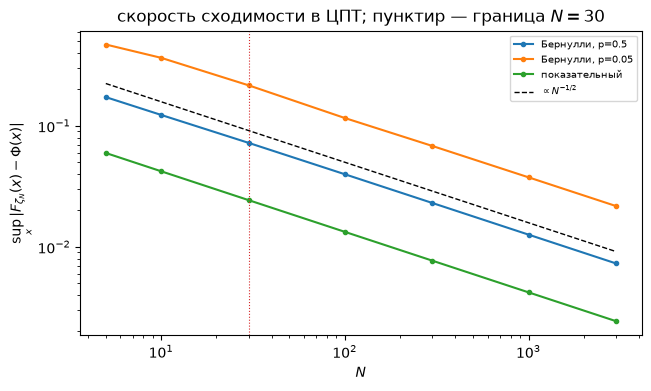

In [14]:
fig, ax = plt.subplots(figsize=(6.4, 3.8), layout="constrained")
for name, d in D.items():
    ax.loglog(N_LIST, d, "o-", ms=3, label=name)
ax.loglog(N_LIST, 0.5 / np.sqrt(N_LIST), "k--", lw=1, label=r"$\propto N^{-1/2}$")
ax.axvline(30, color="C3", lw=0.8, ls=":")
ax.set_xlabel("$N$")
ax.set_ylabel(r"$\sup_x |F_{\zeta_N}(x) - \Phi(x)|$")
ax.set_title("скорость сходимости в ЦПТ; пунктир — граница $N=30$")
ax.legend(fontsize=7)
fig.savefig(f"{FIGDIR}/fig-03.pdf", **SAVE_KW)

## Пример 4. Где ЦПТ ломается: бесконечная дисперсия

**Вопрос.** Что происходит с нормированной суммой, если дисперсия слагаемого
бесконечна? Распределение Парето с $\alpha=1{,}5$: среднее равно
$\alpha/(\alpha-1)=3$, дисперсии нет.

**Предсказание (до прогона).** Нормировка $\sqrt N$ перестаёт быть верной:
сумма $S_N - Na$ имеет масштаб порядка $N^{1/\alpha}$, поэтому разброс
величины $(S_N-Na)/\sqrt N$ должен расти как
$N^{1/\alpha - 1/2} = N^{1/6} \approx N^{0{,}167}$, а разброс
$(S_N-Na)/N^{1/\alpha}$ — выходить на постоянную. Разброс меряем
межквартильным размахом: выборочное стандартное уклонение при бесконечной
дисперсии само неустойчиво и мерить им нельзя.

In [15]:
a_par = ALPHA_PARETO / (ALPHA_PARETO - 1.0)
M_PAR = 40_000
N_PAR = np.array([10, 30, 100, 300, 1000, 3000, 10_000])
iqr_sqrt, iqr_alpha = [], []
for n in N_PAR:
    s = (rng_pareto.pareto(ALPHA_PARETO, (M_PAR, int(n))) + 1.0).sum(axis=1) - n * a_par
    iqr_sqrt.append(np.subtract(*np.percentile(s / np.sqrt(n), [75, 25])))
    iqr_alpha.append(np.subtract(*np.percentile(s / n ** (1 / ALPHA_PARETO), [75, 25])))
iqr_sqrt, iqr_alpha = np.array(iqr_sqrt), np.array(iqr_alpha)

slope_sqrt = np.polyfit(np.log(N_PAR), np.log(iqr_sqrt), 1)[0]
slope_alpha = np.polyfit(np.log(N_PAR), np.log(iqr_alpha), 1)[0]
print(f"{'N':>7} {'IQR / sqrt(N)':>16} {'IQR / N^(1/alpha)':>20}")
for j, n in enumerate(N_PAR):
    print(f"{n:7d} {iqr_sqrt[j]:16.4f} {iqr_alpha[j]:20.4f}")
print(f"\nнаклон в log-log: при нормировке sqrt(N) {slope_sqrt:+.4f} "
      f"(предсказано {1/ALPHA_PARETO - 0.5:+.4f}), "
      f"при нормировке N^(1/alpha) {slope_alpha:+.4f} (предсказано +0.0000)")
# Local slope over the last decade: convergence to the stable law is slow, so the
# global fit is biased low and the local one is closer to the limit.
loc = np.log(N_PAR[-1] / N_PAR[-2])
print(f"локальный наклон на [{N_PAR[-2]}; {N_PAR[-1]}]: "
      f"sqrt(N) {np.log(iqr_sqrt[-1]/iqr_sqrt[-2])/loc:+.4f}, "
      f"N^(1/alpha) {np.log(iqr_alpha[-1]/iqr_alpha[-2])/loc:+.4f}")
# Контроль арифметики, а НЕ проверка теории: обе кривые получены делением одного
# и того же массива на два масштаба, поэтому разность наклонов равна
# 1/alpha - 1/2 тождественно — хоть на выборке Парето, хоть на чистом шуме.
print(f"контроль арифметики: разность наклонов = {slope_sqrt - slope_alpha:+.6f}, "
      f"1/alpha - 1/2 = {1/ALPHA_PARETO - 0.5:+.6f} (тождество)")
local = np.log(N_PAR[-1] / N_PAR[-2])
check_golden("pareto_local_slope", np.log(iqr_sqrt[-1] / iqr_sqrt[-2]) / local)
check_golden("pareto_iqr_alpha_last", iqr_alpha[-1])

      N    IQR / sqrt(N)    IQR / N^(1/alpha)
     10           3.6987               2.5199
     30           5.1050               2.8961
    100           6.9123               3.2084
    300           8.8217               3.4096
   1000          11.3166               3.5786
   3000          13.9047               3.6613
  10000          17.5121               3.7729

наклон в log-log: при нормировке sqrt(N) +0.2221 (предсказано +0.1667), при нормировке N^(1/alpha) +0.0554 (предсказано +0.0000)
локальный наклон на [3000; 10000]: sqrt(N) +0.1916, N^(1/alpha) +0.0249
контроль арифметики: разность наклонов = +0.166667, 1/alpha - 1/2 = +0.166667 (тождество)
  пин pareto_local_slope: получено 0.191586032695, ожидалось 0.191586032695 (допуск 0.06)
  пин pareto_iqr_alpha_last: получено 3.77285951027, ожидалось 3.77285951027 (допуск 0.03)


**Вывод.** Качественно предсказание сбылось, количественно — нет, и
расхождение объясняется.

Качественная часть верна: при нормировке $\sqrt N$ разброс растёт, при
нормировке $N^{1/\alpha}$ почти стабилизируется. Центральная предельная
теорема при бесконечной дисперсии неверна не «приблизительно», а в самой
нормировке: делить надо на другую степень $N$.

Количественно измеренные наклоны — $+0{,}222$ и $+0{,}055$ вместо
предсказанных $+0{,}167$ и $0$. Причина не в постановке примера, а в
медленной сходимости к устойчивому закону при $\alpha=1{,}5$: поправка к
предельному распределению убывает степенью с малым показателем, и на
$N \leq 10^4$ асимптотика ещё не установилась. Свидетельство в пользу
предсказания — локальный наклон на последней декаде: $+0{,}192$ против
глобального $+0{,}222$ при предсказанном $+0{,}167$, то есть при росте $N$
измеренный наклон идёт к предсказанному, а не от него.

**Чего этот пример не проверяет.** Разность наклонов двух кривых равна
$1/\alpha-1/2$ с точностью до шестого знака, и заманчиво предъявить это как
точное подтверждение. Подтверждением оно не является: обе кривые получены
делением **одного и того же** массива сумм на два разных масштаба, поэтому
разность их наклонов равна $1/\alpha-1/2$ тождественно — она получится такой
же на чистом нормальном шуме, в котором никакого Парето нет. Это контроль
арифметики, а не вероятностного утверждения; соответствующая строка вывода
так и подписана.

Практический признак для расчёта: если выборочная дисперсия измерений растёт
с числом измерений вместо того чтобы стабилизироваться, доверительные
интервалы по ЦПТ строить нельзя.

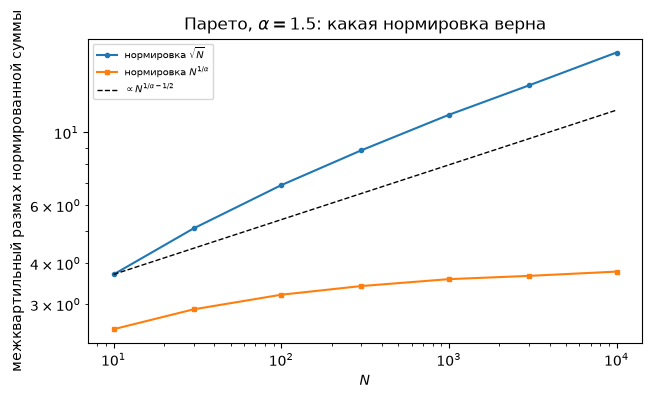

In [16]:
fig, ax = plt.subplots(figsize=(6.4, 3.8), layout="constrained")
ax.loglog(N_PAR, iqr_sqrt, "o-", ms=3, label=r"нормировка $\sqrt{N}$")
ax.loglog(N_PAR, iqr_alpha, "s-", ms=3, label=r"нормировка $N^{1/\alpha}$")
ax.loglog(N_PAR, iqr_sqrt[0] * (N_PAR / N_PAR[0]) ** (1 / ALPHA_PARETO - 0.5),
          "k--", lw=1, label=r"$\propto N^{1/\alpha - 1/2}$")
ax.set_xlabel("$N$")
ax.set_ylabel("межквартильный размах нормированной суммы")
ax.set_title(r"Парето, $\alpha = 1.5$: какая нормировка верна")
ax.legend(fontsize=7)
fig.savefig(f"{FIGDIR}/fig-04.pdf", **SAVE_KW)